# Graph Signal Denoising on Directed Acyclic Graphs (DAGs)

> Notebook purpose: investigate how graph-operator choices affect reconstruction quality for noisy graph signals, with an emphasis on directed constructions and Möbius-inspired operators.

## What This Notebook Contains
- Utility functions for noise modeling and SNR diagnostics.
- Graph generation pipelines (Erdos-Renyi and random geometric structures).
- Directed and undirected operator construction.
- Signal synthesis from low-eigenvector subspaces.
- A trainable iterative denoising model in PyTorch.
- Experimental sweeps over matrix/operator combinations and eigenvector counts.
- Visualization pipelines for publication-style figures.

## Quick Navigation
1. Imports and environment setup
2. Core helpers: noise, connectivity, transitive closure
3. Model definition and training/evaluation loops
4. Graph/operator generation
5. Dataset creation and experiment execution
6. Result visualization and export
7. Post-processing and toy sanity checks


In [ ]:
import torch
from pygsp import graphs
import random
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
from sklearn.metrics import mean_squared_error
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

## 1. Imports and Runtime Setup

This section loads numerical, graph-processing, machine-learning, and plotting dependencies used throughout the notebook.

### Main dependency groups
- Graph handling: `pygsp`, `networkx`
- Numerical computing: `numpy`, `pandas`
- Learning pipeline: `torch`, `sklearn`
- Visualization: `matplotlib`

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
u = torch.rand(250).view(-1, 1)
v = torch.rand(250).view(-1, 1)

## 2. Data Loader and Noise Utilities

The next helper cells define reusable building blocks for dataset creation and perturbation control.

### Utility roles
- `create_loader_from_np`: wraps NumPy arrays into PyTorch dataloaders.
- `add_noiseSNR` / `add_noiseMSE`: inject controlled Gaussian noise.
- `calculate_snr_db`: measures reconstruction quality in decibels.

These helpers standardize experiments so operator comparisons remain fair.

In [44]:
def create_loader_from_np(X, y = None, train = True, batch_size=1, shuffle=True, num_workers = 2):
    if train:
        dataset = TensorDataset(torch.from_numpy(X).type(torch.float), 
                                torch.from_numpy(y).type(torch.long))
    else:
        dataset = TensorDataset(torch.from_numpy(X).type(torch.float))
    loader = DataLoader(dataset=dataset,
                        batch_size=batch_size,
                        shuffle=shuffle,
                        pin_memory=True, num_workers=num_workers)
    return loader

In [4]:
def add_noiseSNR(signal, snr_db):
    snr_linear = 10 ** (snr_db / 10)
    signal_power = np.mean(signal**2)
    noise_power = signal_power / snr_linear
    noise = np.random.normal(0, np.sqrt(noise_power), signal.shape)
    noisy_signal = signal + noise
    return noisy_signal

In [142]:
def add_noiseMSE(signal, mse):
    noise = np.random.normal(0, mse, signal.shape)
    noisy_signal = signal + noise
    return noisy_signal

In [6]:
def calculate_snr_db(original_signal, noisy_signal):
    signal_power = np.mean(original_signal**2)
    noise = noisy_signal - original_signal
    noise_power = np.mean(noise**2)
    snr_db = 10 * np.log10(signal_power / noise_power)
    return snr_db

In [7]:
def soft_thresholding(x, lambda_1, gamma):
    return torch.sign(x) * torch.max(torch.abs(x) - lambda_1 * gamma, torch.tensor(0.0))

class MyModel(torch.nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.L=10
        L = 10
        #there should be 10 of each gamma, lambda_1, lambda_2
        self.gamma = torch.nn.Parameter(torch.rand(L), requires_grad=True)
        self.lambda_1 = torch.nn.Parameter(torch.rand(L), requires_grad=True)
        self.lambda_2 = torch.nn.Parameter(torch.rand(L), requires_grad=True)

    def forward(self, M, y, v, u):                    
        for l in range(self.L):
            I = torch.eye(250)
            M_T_M = torch.matmul(M, torch.transpose(M, 0, 1))
            term1 = torch.linalg.inv(I + 1/self.gamma[l] * M_T_M)
            term2 = y + 1/self.gamma[l] * torch.matmul(M, (v - u))
            x = torch.matmul(term1, term2)
            term1 = 1 / (1 + self.lambda_2[l] * self.gamma[l])
            term2 = torch.matmul(torch.transpose(M, 0, 1), x) + u
            v = term1 * soft_thresholding(term2, self.lambda_1[l], self.gamma[l])
            u = u + torch.matmul(torch.transpose(M, 0, 1), x) - v  
        return x          

## 3. Iterative Denoising Model

This block defines a learnable iterative solver inspired by optimization-style updates.

### Model intuition
At each layer/iteration, the model updates primal and auxiliary variables using matrix transforms and soft-thresholding. Parameters (`gamma`, `lambda_1`, `lambda_2`) are trainable per iteration, letting the network adapt shrinkage and update strength.

### Key takeaway
The architecture combines classical signal-recovery structure with learnable coefficients, making it interpretable while still trainable end-to-end.

In [86]:
def is_connected(adj_matrix):
    adj_matrix = adj_matrix + adj_matrix.T
    n = len(adj_matrix)  # Number of nodes in the graph
    visited = [False] * n  # Keep track of visited nodes

    # Perform DFS starting from node 0
    def dfs(node):
        visited[node] = True
        for neighbor, connected in enumerate(adj_matrix[node]):
            if connected and not visited[neighbor]:
                dfs(neighbor)

    # Start DFS from the first node (node 0)
    dfs(0)

    # Check if all nodes are visited
    return all(visited)

## 4. Graph Generation and Structural Checks

This section introduces connectivity validation and random graph generation procedures.

### Included generators
- Erdos-Renyi generator with connectivity constraints.
- Random geometric graph generator using Euclidean thresholding.

The connectivity check ensures generated structures are usable for downstream operator construction and signal propagation analyses.

In [118]:
def generateErdosRenyiGraph(n):
    connected = False
    k = 0
    while (not connected):
        G = graphs.ErdosRenyi(N=n, p=0.025, directed = False, connected=True, max_iter=100)
        A = G.A.todense()
        A = np.triu(A)
        connected = is_connected(A)
        print(connected)
        G = graphs.Graph(A)
        if(connected):
            return G
        k += 1
        print(k)
    return G

In [91]:
def generateRandomGeoGraph(N):
    threshold = 0.09
    connected = False
    k=0
    while(not connected):
        # Generate N random points in the unit square
        X = np.random.rand(N, 2)
        # Generate an adjacaency matrix of a graph where the nodes are the points and the edges if the distance between the nodes is less than 0.065
        dist = np.zeros((N, N))
        for i in range(N):
            for j in range(N):
                dist[i, j] = np.linalg.norm(X[i] - X[j])
                if i == j:
                    dist[i, j] = threshold +1
        A = dist < threshold
        A = np.triu(A)
        connected = is_connected(A)
        print(k)
        k+=1
    return graphs.Graph(A)


In [51]:
def transititive_closure(matrix):
    n = len(matrix)
    closure = np.copy(matrix)
    for k in range(n):
        for i in range(n):
            for j in range(n):
                closure[i][j] = closure[i][j] or (closure[i][k] and closure[k][j])

    return closure

## 5. Directed and Undirected Operator Families

The next cells build matrix operators used both for signal generation and model training.

### Directed set
- Shift-style operator
- Directed Laplacian variants
- Möbius, Möbius-Laplacian, and modified Möbius forms (via transitive closure)

### Undirected set
- Standard/normalized Laplacians
- Left-normalized Laplacian
- Incidence and normalized incidence matrices

This enables systematic cross-comparison: generate with one operator family, train with another, and observe transfer behavior.

In [10]:
def generatedirectedMatrices(G):
    matrices = {}

    # Shift matrix
    A = G.W.toarray()
    I = np.eye(G.N)
    M_shift = I - A
    matrices['M_shift'] = M_shift

    # Laplacian matrix
    D = np.diag(np.sum(A, axis=0))
    L = D - A
    matrices['M_laplacian'] = L

    # Normalized Laplacian
    A_selfloop = np.copy(A)
    for i in range(G.N):
        A_selfloop[i, i] = 1
    D = np.diag(np.sum(A_selfloop, axis=0))
    D_inv = np.linalg.inv(D)
    M_normalizedLaplacian = np.eye(G.N) - np.matmul(D_inv, A_selfloop)
    matrices['M_normalizedLaplacian'] = M_normalizedLaplacian

    # Moebius matrices
    closure = transititive_closure(A_selfloop)
    M_moebius = np.linalg.inv(closure)
    matrices['M_moebius'] = M_moebius

    D_M = np.diag(np.sum(M_moebius, axis=0))
    M_moebiusLaplacian = M_moebius - D_M
    matrices['M_moebiusLaplacian'] = M_moebiusLaplacian

    D_modified = np.sum(M_moebius, axis=0) / G.N
    M_modifiedMoebius = M_moebius - D_modified
    matrices['M_modifiedMoebius'] = M_modifiedMoebius

    return matrices


In [156]:
def generateundirectedMatrices(G):
    matrices = {}
    A = G.W.toarray()
    I = np.eye(G.N)
    A_sym = A.T + A

    M_shift = I - A_sym
    matrices['M_shift'] = M_shift

    #calculate the laplacian matrix of A_sym
    D = np.diag(np.sum(A_sym, axis=0))
    L = D - A_sym
    matrices['M_laplacian'] = L

    #calculate the normalized laplacian matrix of A_sym
    D_inv = np.linalg.inv(D)
    D_inv_sqrt = np.sqrt(D_inv)
    M_normalizedLaplacian = I - np.matmul(np.matmul(D_inv_sqrt, A_sym), D_inv_sqrt)
    matrices['M_normalizedLaplacian'] = M_normalizedLaplacian

    #calculate the left normalized laplacian matrix of A_sym
    M_leftNormalizedLaplacian = I - np.matmul(D_inv, A_sym)
    matrices['M_leftNormalizedLaplacian'] = M_leftNormalizedLaplacian

    #calculate the oriented incidence matrix
    B = nx.incidence_matrix(nx.Graph(A_sym), oriented=True).toarray()
    B = B.T
    print(B.shape)
    matrices['M_incidence'] = B

    #cakculate the normalized incidence matrix
    M_normalizedIncidence = np.matmul(B, D_inv_sqrt)
    matrices['M_normalizedIncidence'] = M_normalizedIncidence

    return matrices

In [141]:
def generateSignals(matrix, evs, SNR):
    _, eigenbasis = np.linalg.eig(matrix @ matrix.transpose())
    lowest_eigenvectors = eigenbasis[:, :evs]
    lowest_eigenvectors = np.real(lowest_eigenvectors)
    signals = []
    for _ in range(600):
        coefficients = np.random.randn(evs)
        combination = np.matmul(lowest_eigenvectors, coefficients)
        signals.append(combination)
    signals = np.array(signals)
    #generate noisy signals with 5 signal to noise ratio
    
    noisy_signals = [add_noiseMSE(signal, SNR) for signal in signals]

    return np.array(signals), np.array(noisy_signals)

## 6. Signal Synthesis and Dataset Splits

This section creates clean/noisy signal pairs and partitions them into training, validation, and test subsets.

### Signal construction strategy
Signals are sampled from low-eigenvector subspaces of $MM^T$, controlling smoothness complexity via the selected eigenvector count.

### Why this matters
By varying eigenvector count and noise level, you stress-test denoising robustness under different spectral complexities.

In [13]:
def getSets(signals, noisy_signals):
    train_signals, testval_signals = train_test_split(signals, train_size=500, shuffle=False)
    val_signals, test_signals = train_test_split(testval_signals, test_size=50, shuffle=False)

    train_noisy_signals, testval_noisy_signals = train_test_split(noisy_signals, train_size=500, shuffle=False)
    val_noisy_signals, test_noisy_signals = train_test_split(testval_noisy_signals, test_size=50, shuffle=False)

    train_set = create_loader_from_np(X=train_noisy_signals, y=train_signals)
    val_set = create_loader_from_np(X=val_noisy_signals, y=val_signals)
    test_set = create_loader_from_np(X=test_noisy_signals, y=test_signals)
    return train_set, val_set, test_set, test_signals

In [138]:
class CustomLoss(nn.Module):
    def __init__(self):
        super(CustomLoss, self).__init__()

    def forward(self, output, target):
        signal_power = torch.mean(target**2)
        noise = output - target
        print(noise)
        noise_power = torch.mean(noise**2)
        print(signal_power, noise_power)
        epsilon = 1e-8
        snr_db = 10 * torch.log10(signal_power / (noise_power+epsilon))
        return -snr_db

## 7. Training and Evaluation Pipeline

The following cells define the optimization procedure and inference loop used in all experiments.

### Training notes
- Loss: Mean Squared Error by default (custom SNR-based loss also provided).
- Optimizer: Adam with a step scheduler.
- Output: trained iterative model ready for operator-wise comparison.

### Evaluation output
Predicted denoised signals are compared against clean references using MSE for aggregate benchmarking.

In [140]:
def train_model(M, train_set, val_set):
    M_torch = torch.from_numpy(M).type(torch.float).to(device)
    model = MyModel()
    model.to(device)
    n_epochs = 3
    optimizer = torch.optim.Adam(model.parameters(), lr=0.02)
    criterion = nn.MSELoss().to(device)
    #criterion = CustomLoss().to(device)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.6)
    
    for epoch in range(n_epochs):
        running_loss = 0.0
        for i, data in enumerate(train_set):
            X, y = data
            X = X.view(-1, 1)
            optimizer.zero_grad()
            outputs = model(M_torch, X, v, u).squeeze()
            loss = criterion(outputs, y.float().squeeze())
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        val_loss = 0.0
        with torch.no_grad():
            for i, data in enumerate(val_set):
                X, y = data
                X = X.view(-1, 1)
                X = X.to(device)
                y = y.to(device)
                output = model.forward(M_torch, X, v, u).squeeze()
                loss = criterion(output, y.float().squeeze())
                val_loss += loss.item()        
        val_loss /= len(val_set)
        print('Epoch [{}/{}], Training Loss: {:.4f}, Validation Loss: {:.4f}'.format(epoch+1, n_epochs, running_loss/len(train_set), val_loss))
        scheduler.step()
    return model

In [16]:
def test_model(model, M, test_set):
    M_torch = torch.from_numpy(M).type(torch.float).to(device)
    model.eval()  # Set the model to evaluation mode
    predictions = []
    with torch.no_grad():
        for i, data in enumerate(test_set):
            X, y = data
            X = X.view(-1, 1)
            X = X.to(device)
            output = model.forward(M_torch, X, v, u).squeeze()
            predictions.append(output.cpu().numpy().reshape(1, -1))
    predictions = np.concatenate(predictions, axis=0)
    return predictions


In [157]:
G = generateRandomGeoGraph(250)
# Eigenvalue counts to iterate over
eigenvector_counts = [3, 5, 7, 10, 13, 16, 20]
matrices = generatedirectedMatrices(G)
snr_db = 5
results = []

0


## 8. Experiment Configuration

This block initializes the graph instance, candidate operator dictionaries, spectral complexity values, and result container.

### Experiment axes
- Eigenvector count (controls signal complexity)
- Signal-generation operator
- Model-training operator

These dimensions define the full grid explored in the subsequent sweep.

In [ ]:
#just for testing
"""

ev_count = 3
#M_shift, M_moebius, M_modifiedMoebius, M_moebiusLaplacian, M_normalizedLaplacian, M_laplacian
signals, noisy_signals = generateSignals(matrices['M_shift'], ev_count, snr_db)
train_set, val_set, test_set, test_signals = getSets(signals, noisy_signals)
trained_model = train_model(matrices['M_shift'], train_set, val_set)
predictions = test_model(trained_model, matrices['M_shift'], test_set)
mse_pred = mean_squared_error(test_signals, predictions)

"""

In [144]:
eigenvector_counts = [3, 6, 10, 13, 16, 20]
for ev_count in eigenvector_counts:
    for signalmatrix_name, signalmatrix in matrices.items():
        signals, noisy_signals = generateSignals(signalmatrix, ev_count, 0.5)
        train_set, val_set, test_set, test_signals = getSets(signals, noisy_signals)
        for trainmatrix_name, trainmatrix in matrices.items():#
            print(f'Signal generated with {signalmatrix_name} and model trained with {trainmatrix_name}')
            trained_model = train_model(trainmatrix, train_set, val_set)
            predictions = test_model(trained_model, trainmatrix, test_set)
            mse_pred = mean_squared_error(test_signals, predictions)
            print(f'MSE: {mse_pred}')
            results.append({
                'Eigenvector Count': ev_count,
                'Signal Matrix Type': signalmatrix_name,
                'Model Matrix Type': trainmatrix_name,
                'MSE': mse_pred
            })

    # Convert results to DataFrame and save to CSV
    df_results = pd.DataFrame(results)
    df_results.to_csv('results_directed_geo.csv', index=False)




Signal generated with M_shift and model trained with M_shift
Epoch [1/3], Training Loss: 0.0248, Validation Loss: 0.0204
Epoch [2/3], Training Loss: 0.0212, Validation Loss: 0.0218
Epoch [3/3], Training Loss: 0.0211, Validation Loss: 0.0261
MSE: 0.04735760239487327
Signal generated with M_shift and model trained with M_laplacian
Epoch [1/3], Training Loss: 0.0575, Validation Loss: 0.0581
Epoch [2/3], Training Loss: 0.0573, Validation Loss: 0.0581
Epoch [3/3], Training Loss: 0.0573, Validation Loss: 0.0581
MSE: 0.08118151745661592
Signal generated with M_shift and model trained with M_normalizedLaplacian
Epoch [1/3], Training Loss: 0.0544, Validation Loss: 0.0568
Epoch [2/3], Training Loss: 0.0525, Validation Loss: 0.0510
Epoch [3/3], Training Loss: 0.0506, Validation Loss: 0.0500
MSE: 0.07138985785014224
Signal generated with M_shift and model trained with M_moebius
Epoch [1/3], Training Loss: 0.0399, Validation Loss: 0.0158
Epoch [2/3], Training Loss: 0.0111, Validation Loss: 0.0108
E

## 9. Full Cross-Operator Sweep

The next loop executes the central benchmark:
- generate signals with one operator
- train with another operator
- evaluate reconstruction MSE
- append each run to a result table

This produces a dense matrix of compatibility/performance outcomes for later analysis and plotting.

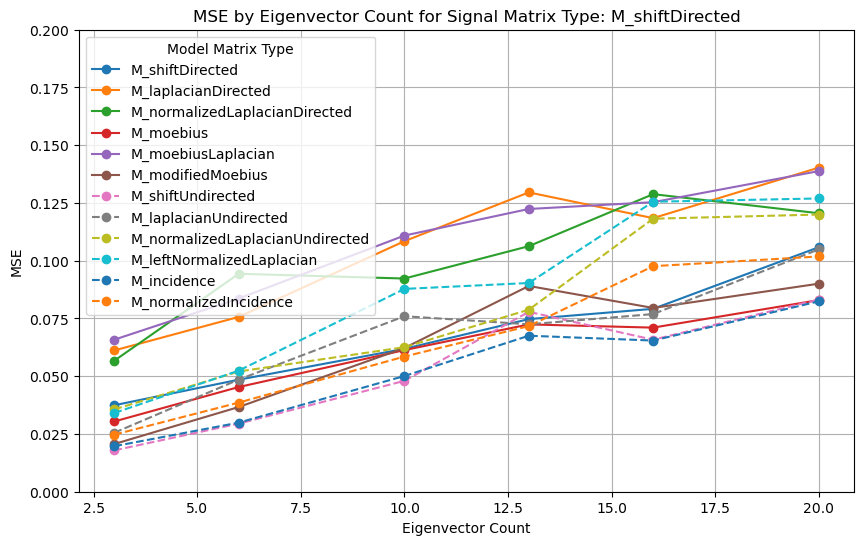

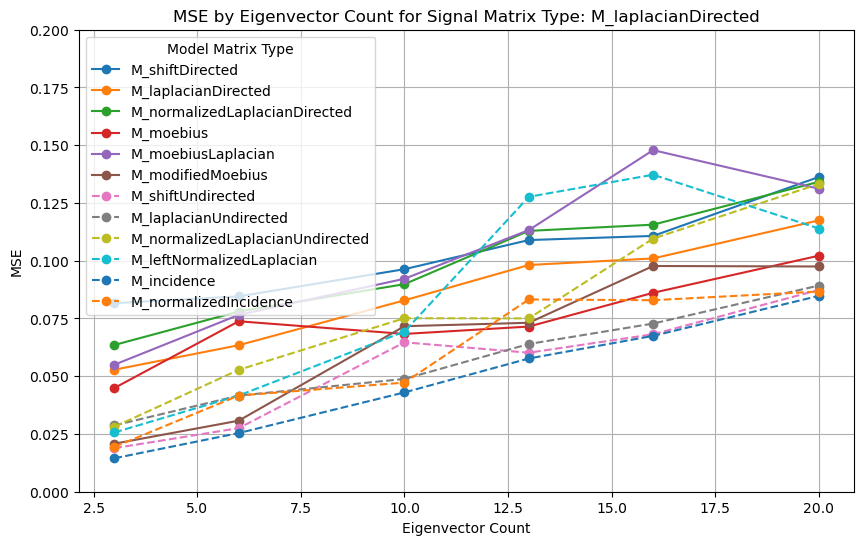

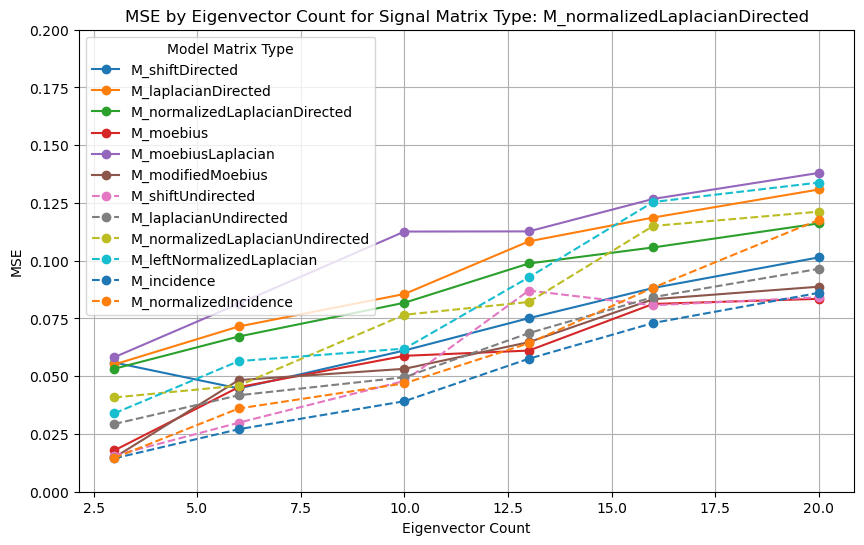

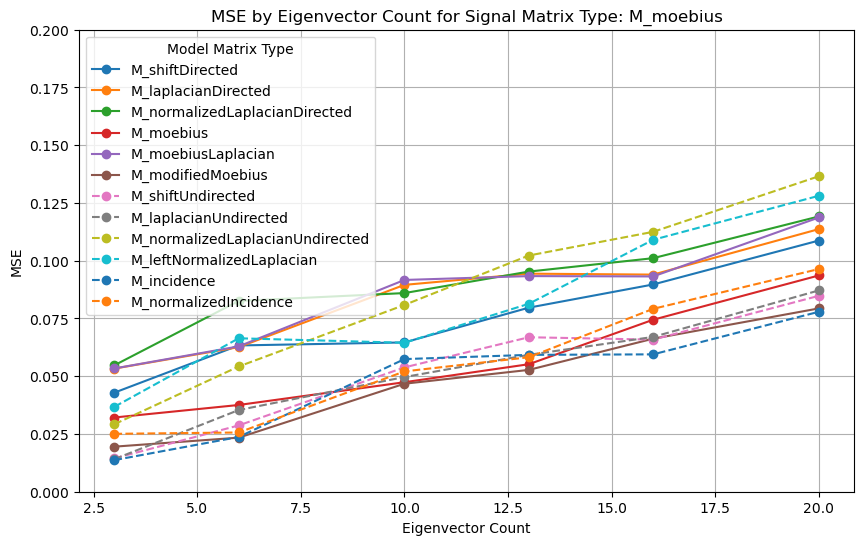

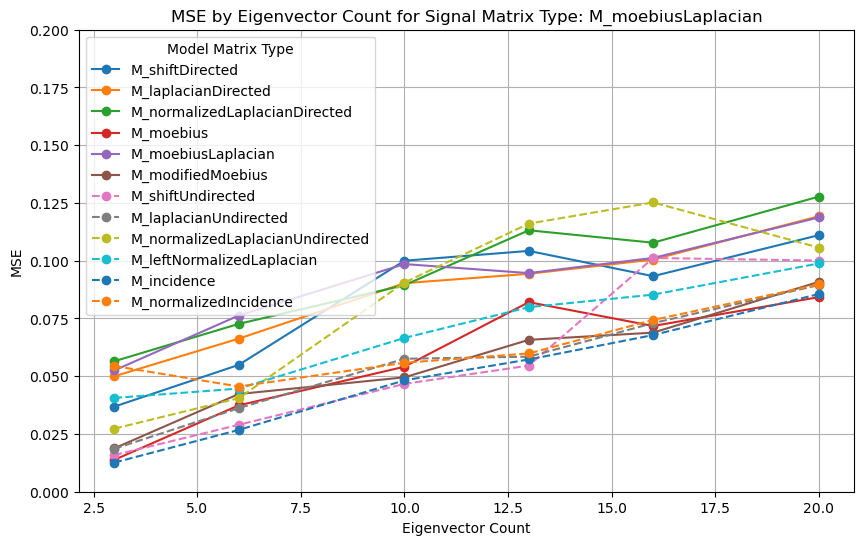

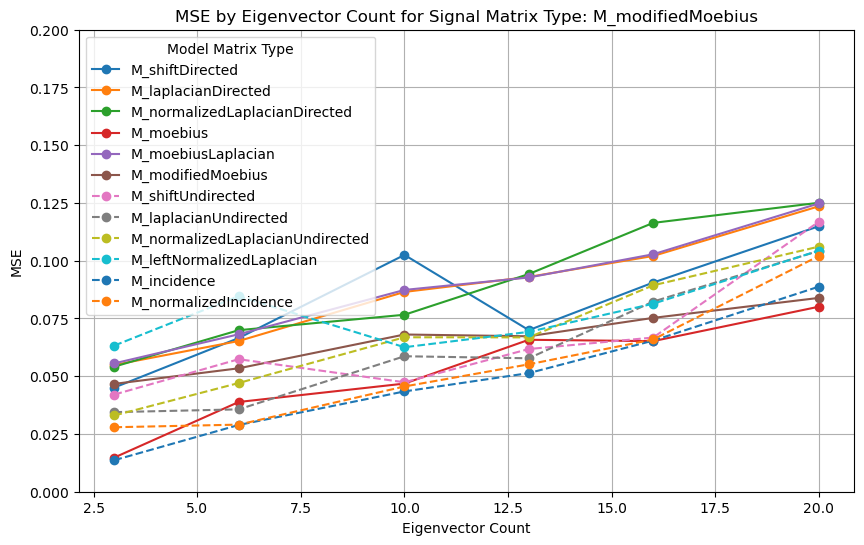

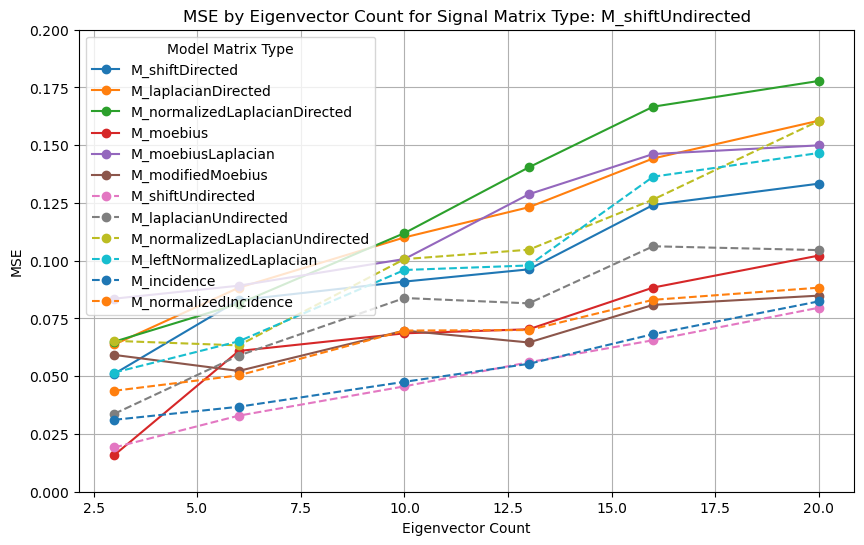

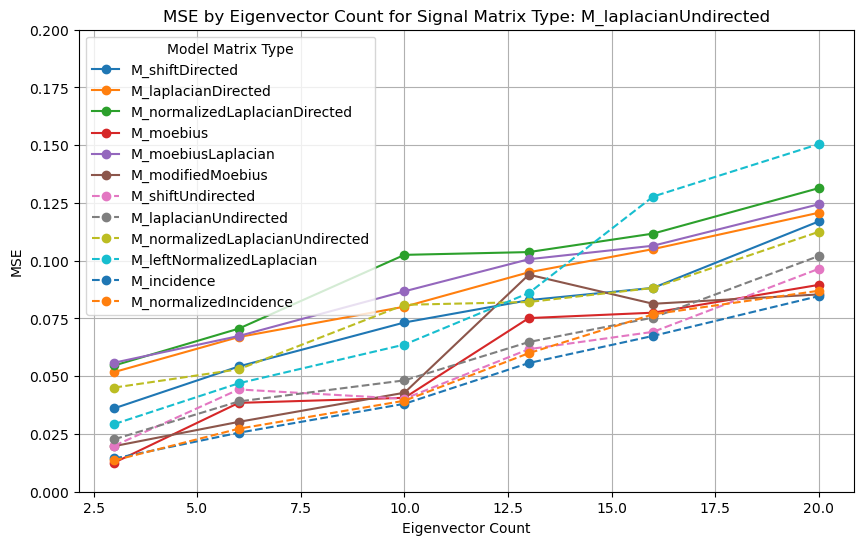

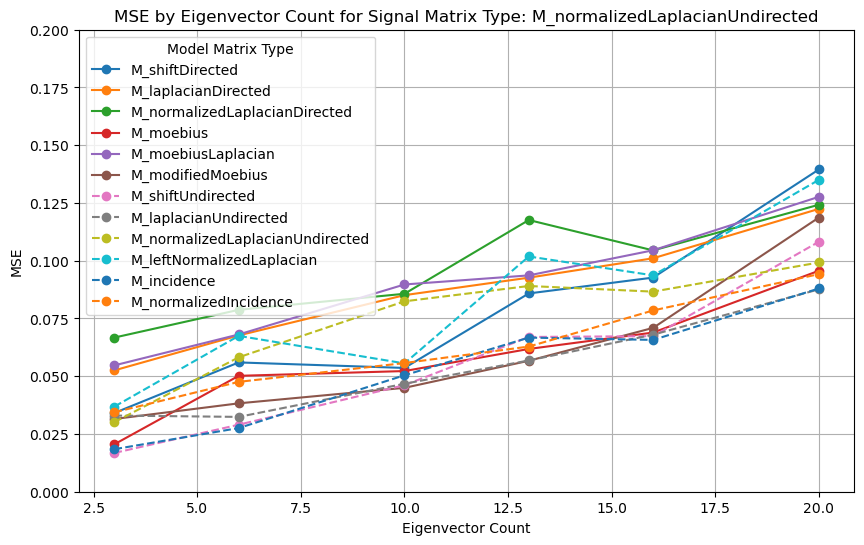

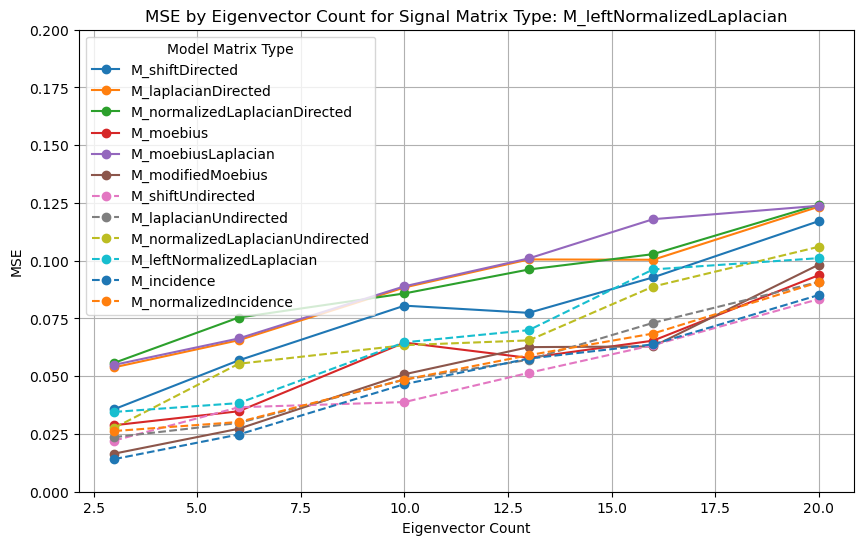

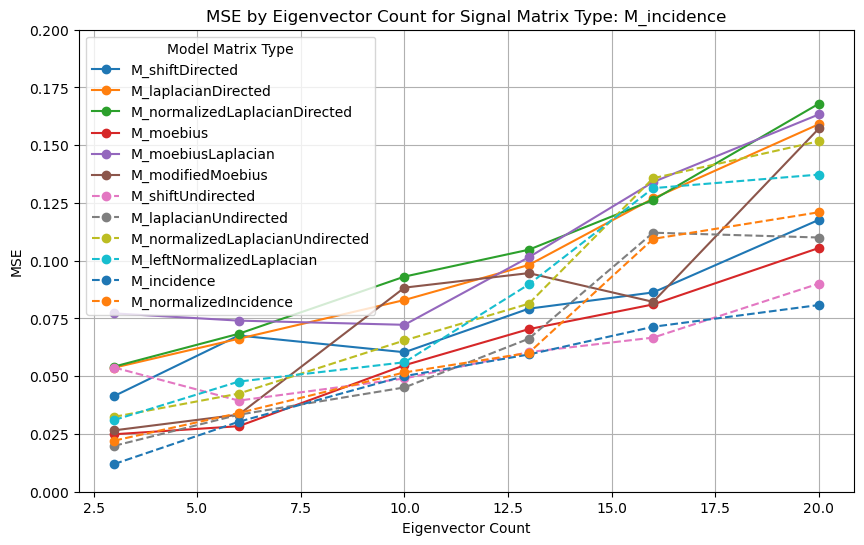

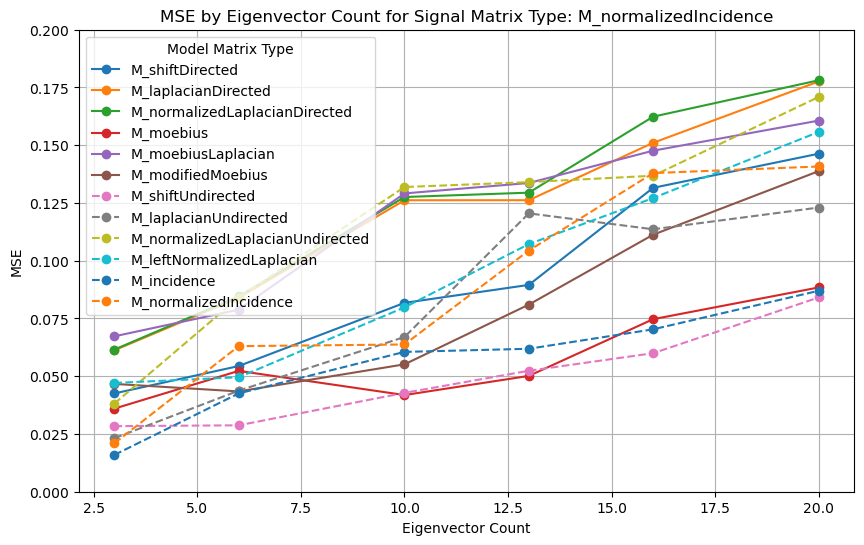

In [45]:
name_mapping = {
    'M_shiftDirected': 'Directed shift',
    'M_laplacianDirected': 'Directed Laplacian',
    'M_normalizedLaplacianDirected': 'Normalized directed Laplacian',
    'M_moebius': 'Möbius matrix',
    'M_moebiusLaplacian': 'Möbius Laplacian',
    'M_modifiedMoebius': 'Modified Möbius matrix',
    'M_shiftUndirected': 'Undirected shift',
    'M_laplacianUndirected': 'Undirected Laplacian',
    'M_normalizedLaplacianUndirected': 'Normalized undirected Laplacian',
    'M_leftNormalizedLaplacian': 'Left normalized undirected Laplacian',
    'M_incidence': 'Oriented incidence matrix',
    'M_normalizedIncidence': 'Normalized oriented incidence matrix'
}

custom_colors = {
    'M_shiftDirected': '#1f77b4',  # blue
    'M_laplacianDirected': '#ff7f0e',  # orange
    'M_normalizedLaplacianDirected': '#2ca02c',  # green
    'M_moebius': '#d62728',  # red
    'M_moebiusLaplacian': '#9467bd',  # purple
    'M_modifiedMoebius': '#8c564b',  # brown
    'M_shiftUndirected': '#1f77b4',  # blue
    'M_laplacianUndirected': '#ff7f0e',  # orange
    'M_normalizedLaplacianUndirected': '#2ca02c',  # green
    'M_leftNormalizedLaplacian': '#d62728',  # red
    'M_incidence': '#9467bd',  # purple
    'M_normalizedIncidence': '#8c564b'   # brown
}

df = pd.read_csv('results.csv')

# Get unique signal matrix types
signal_matrix_types = df['Signal Matrix Type'].unique()
dashed_matrices = ['M_shiftUndirected', 'M_laplacianUndirected', 'M_normalizedLaplacianUndirected', 'M_leftNormalizedLaplacian', 'M_incidence', 'M_normalizedIncidence']
    

# Create a plot for each Signal Matrix Type
for signal_type in signal_matrix_types:
    # Filter the data for the current Signal Matrix Type
    filtered_df = df[df['Signal Matrix Type'] == signal_type]
    # Initialize the plot
    plt.figure(figsize=(10, 6))
    ax = plt.gca()
    
    # Plot data and fit model for each Model Matrix Type
    for model_type in filtered_df['Model Matrix Type'].unique():
        subset = filtered_df[filtered_df['Model Matrix Type'] == model_type]
        subset = subset.sort_values(by='Eigenvector Count')
        line_style = '--' if model_type in dashed_matrices else '-'
        color = custom_colors[model_type]
        ax.plot(subset['Eigenvector Count'], subset['MSE'], label=f'{model_type}', linestyle=line_style, color=color)
        
    # Set plot titles and labels
    friendly_name = name_mapping.get(signal_type, signal_type)
    ax.set_title(f'Signal Matrix: {friendly_name}', fontsize=20)
    ax.set_xlabel('Eigenvector Count', fontsize=18)
    ax.set_ylabel('MSE', fontsize=18)
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.set_ylim(0, 0.2)
    # Show the plot
    plt.show()

## 10. Visualization: Raw Curves by Signal Type

The plotting block below generates one figure per signal-generation operator and overlays model-operator performance curves.

### Read this plot as
- X-axis: eigenvector count
- Y-axis: denoising MSE (lower is better)
- Color/style: matrix/operator identity

This view highlights where model/operator pairings are robust or fragile across spectral complexity.

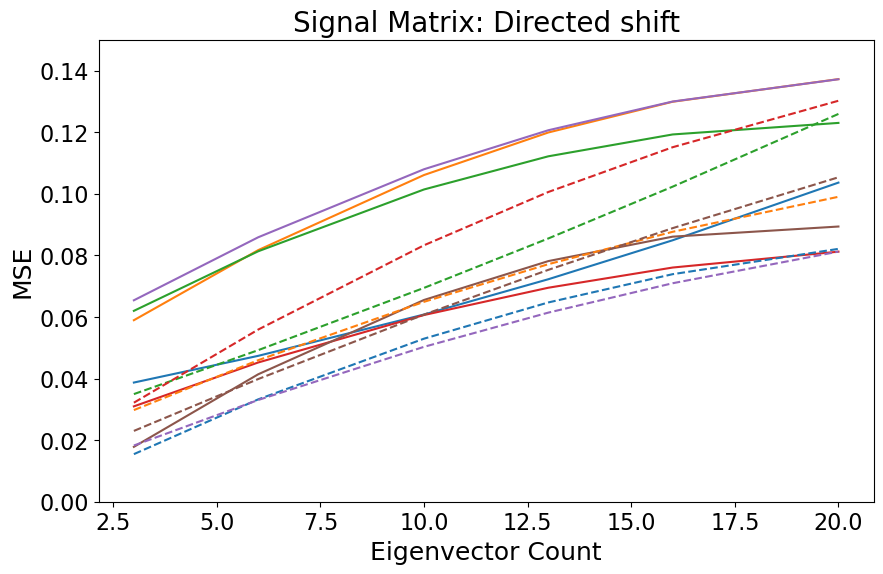

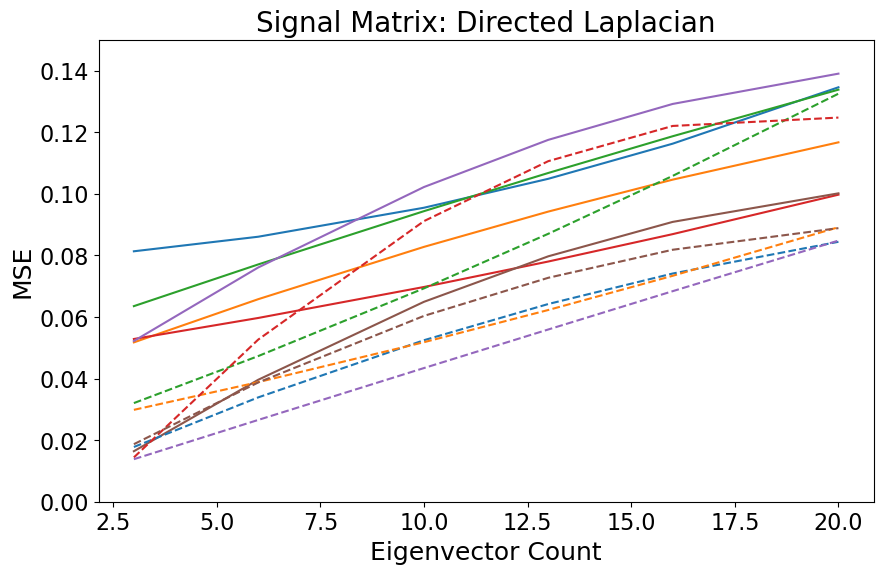

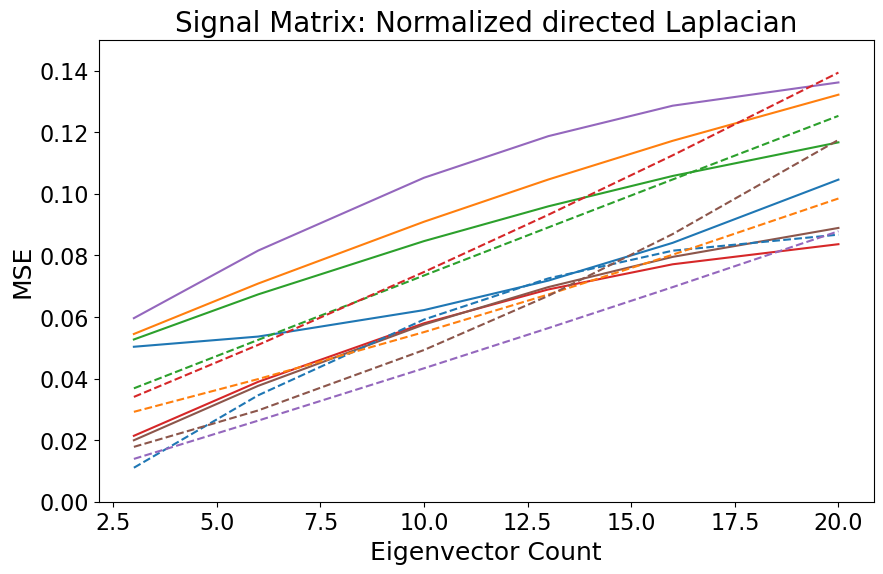

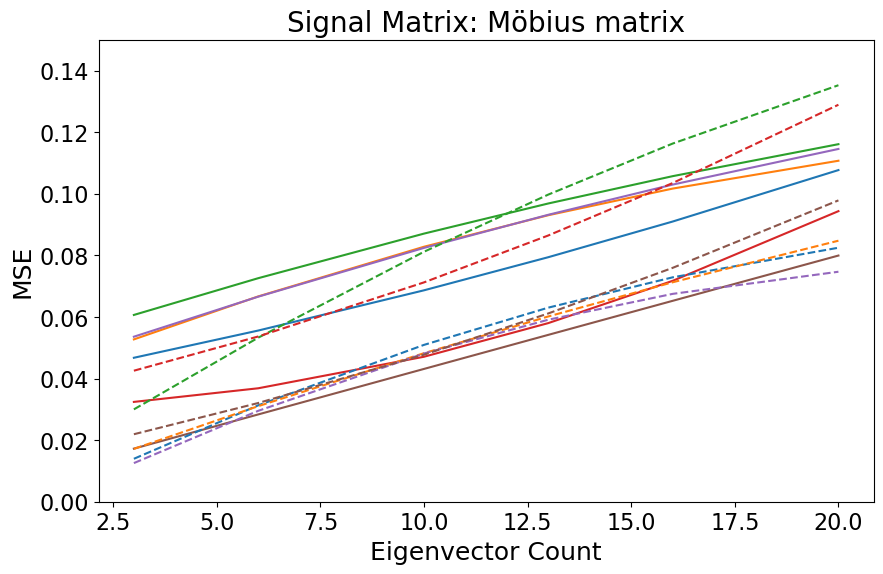

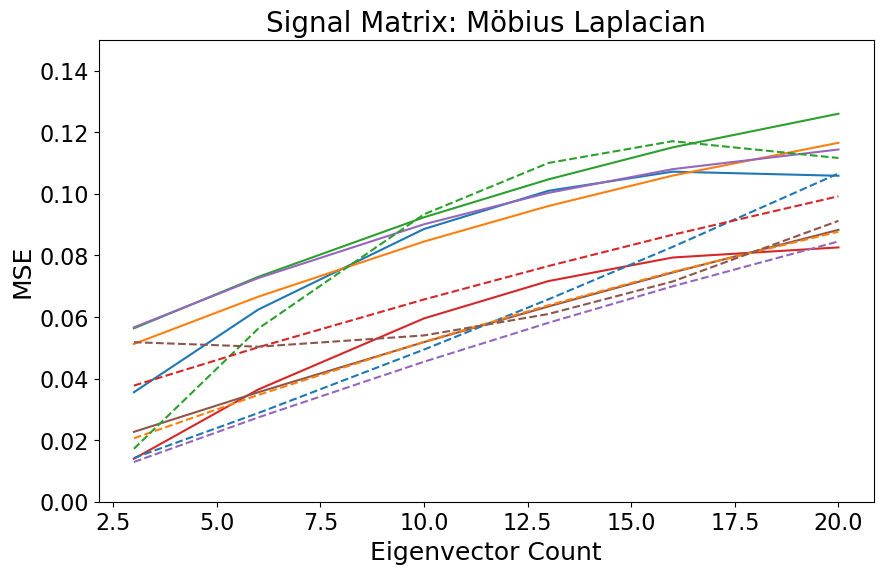

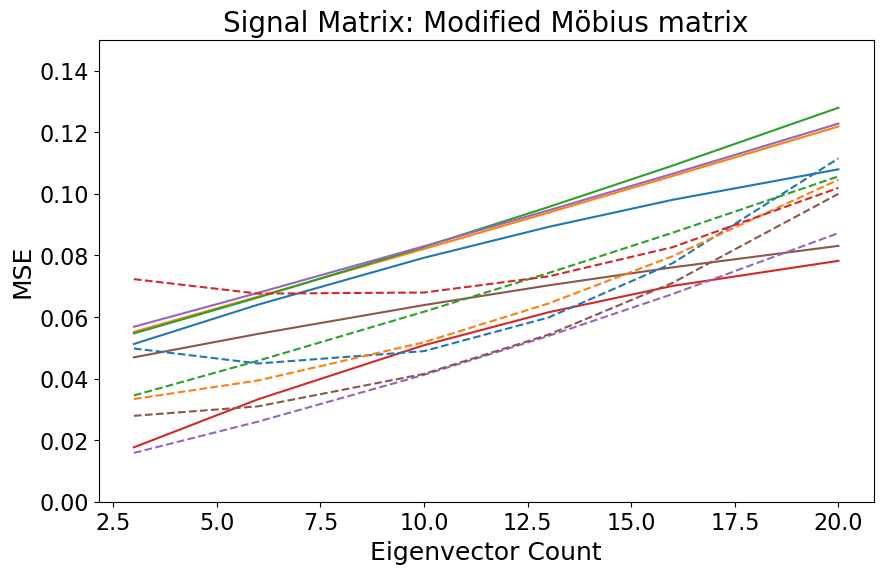

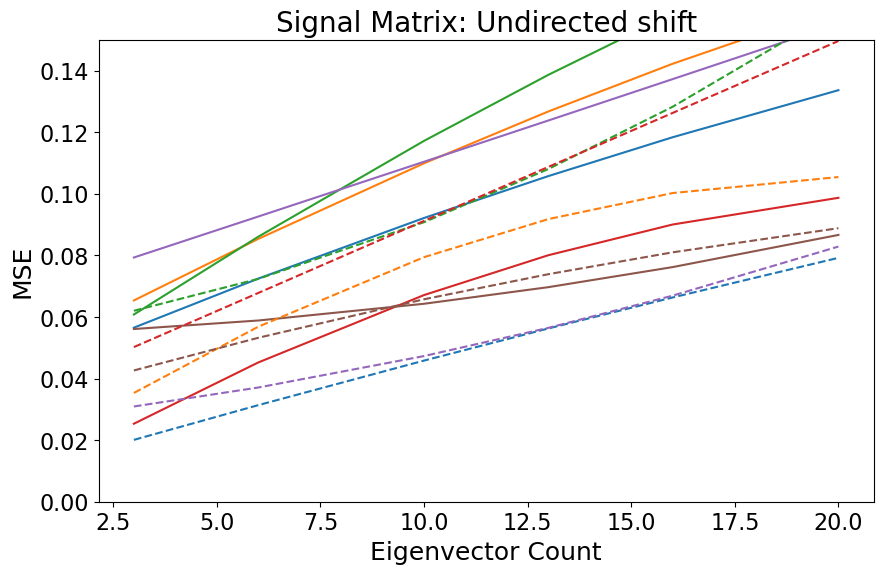

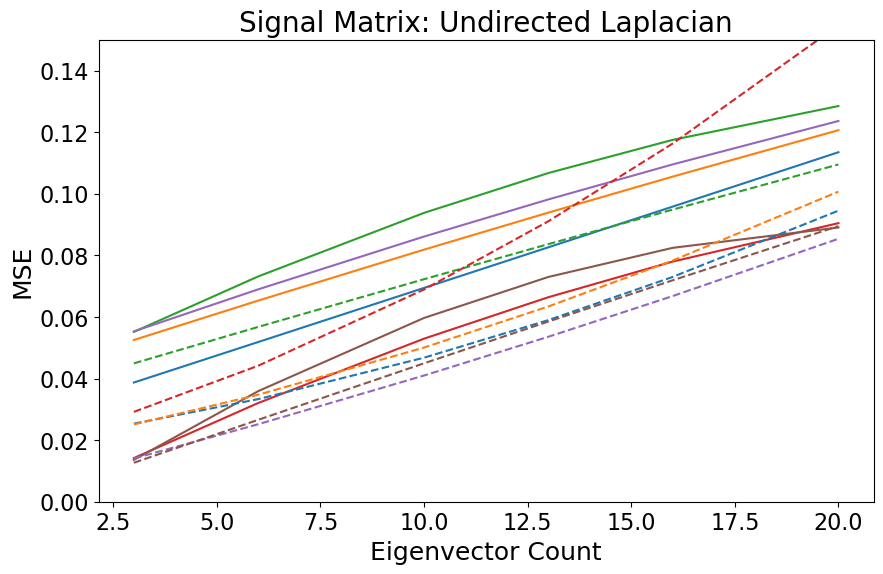

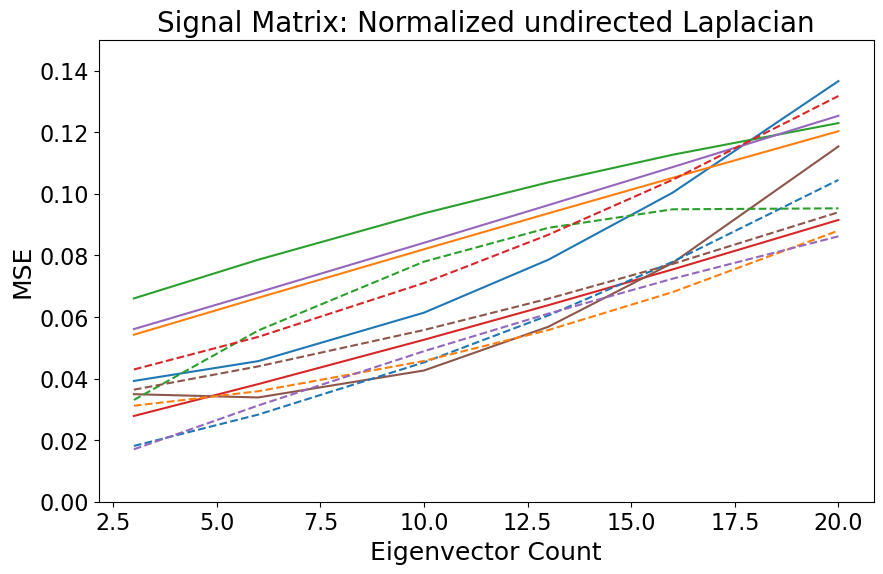

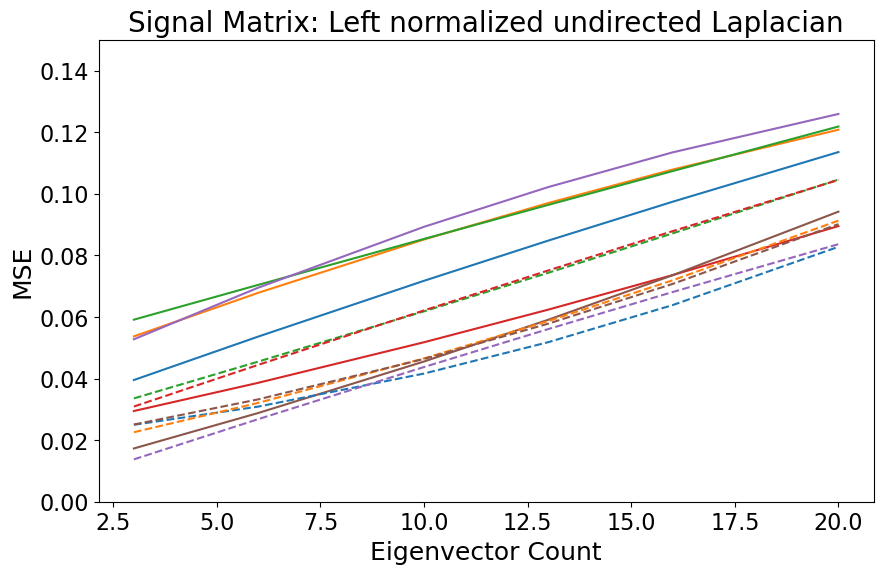

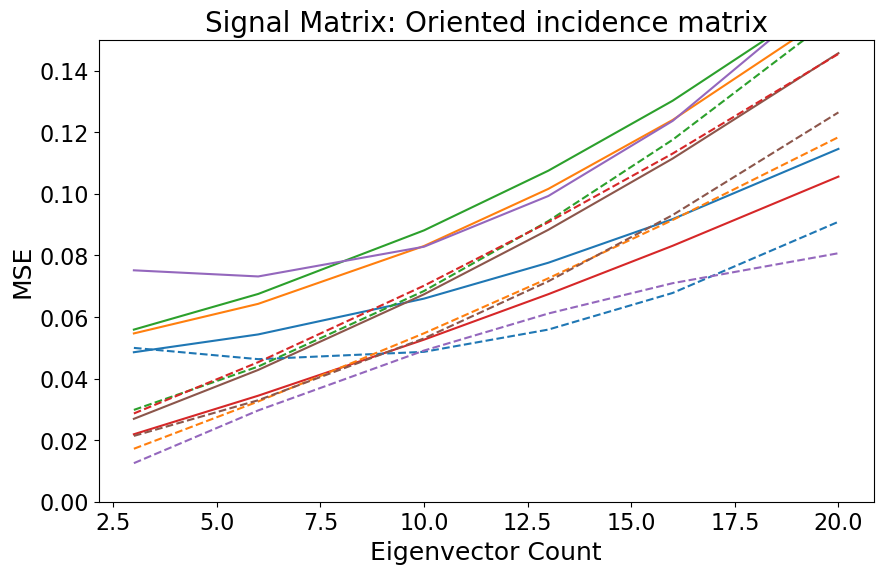

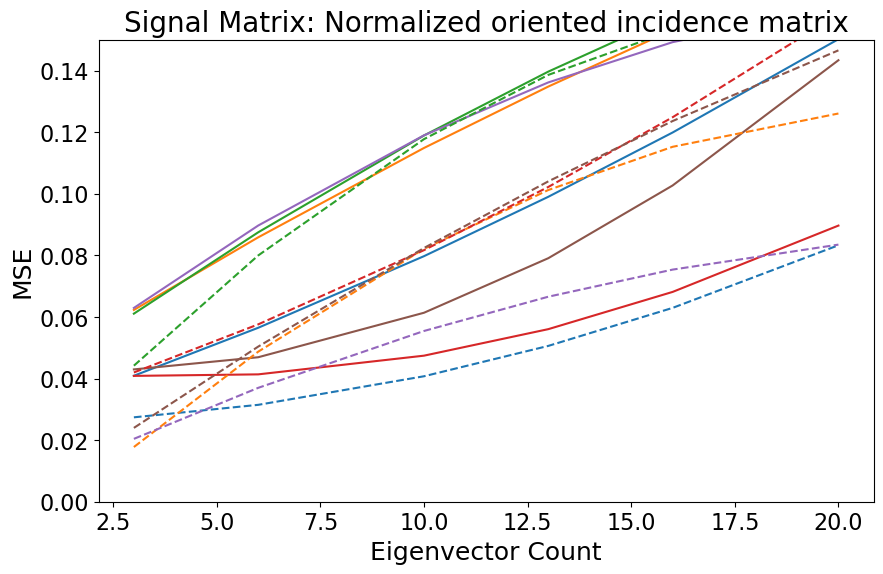

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import os

name_mapping = {
    'M_shiftDirected': 'Directed shift',
    'M_laplacianDirected': 'Directed Laplacian',
    'M_normalizedLaplacianDirected': 'Normalized directed Laplacian',
    'M_moebius': 'Möbius matrix',
    'M_moebiusLaplacian': 'Möbius Laplacian',
    'M_modifiedMoebius': 'Modified Möbius matrix',
    'M_shiftUndirected': 'Undirected shift',
    'M_laplacianUndirected': 'Undirected Laplacian',
    'M_normalizedLaplacianUndirected': 'Normalized undirected Laplacian',
    'M_leftNormalizedLaplacian': 'Left normalized undirected Laplacian',
    'M_incidence': 'Oriented incidence matrix',
    'M_normalizedIncidence': 'Normalized oriented incidence matrix'
}

custom_colors = {
    'M_shiftDirected': '#1f77b4',  # blue
    'M_laplacianDirected': '#ff7f0e',  # orange
    'M_normalizedLaplacianDirected': '#2ca02c',  # green
    'M_moebius': '#d62728',  # red
    'M_moebiusLaplacian': '#9467bd',  # purple
    'M_modifiedMoebius': '#8c564b',  # brown
    'M_shiftUndirected': '#1f77b4',  # blue
    'M_laplacianUndirected': '#ff7f0e',  # orange
    'M_normalizedLaplacianUndirected': '#2ca02c',  # green
    'M_leftNormalizedLaplacian': '#d62728',  # red
    'M_incidence': '#9467bd',  # purple
    'M_normalizedIncidence': '#8c564b'   # brown
}


# Load data
df = pd.read_csv('RandomGeoResults.csv')

# Get unique signal matrix types
signal_matrix_types = df['Signal Matrix Type'].unique()
dashed_matrices = ['M_shiftUndirected', 'M_laplacianUndirected', 'M_normalizedLaplacianUndirected', 
                   'M_leftNormalizedLaplacian', 'M_incidence', 'M_normalizedIncidence']

# Create a plot for each Signal Matrix Type
for signal_type in signal_matrix_types:
    # Filter the data for the current Signal Matrix Type
    filtered_df = df[df['Signal Matrix Type'] == signal_type]
    
    # Initialize the plot
    plt.figure(figsize=(10, 6))
    ax = plt.gca()
    
    # Plot data and fit model for each Model Matrix Type
    for model_type in filtered_df['Model Matrix Type'].unique():
        subset = filtered_df[filtered_df['Model Matrix Type'] == model_type]
        subset = subset.sort_values(by='Eigenvector Count')
        x = subset['Eigenvector Count'].values.reshape(-1, 1)
        y = subset['MSE'].values
        
        # Create polynomial features
        poly_features = PolynomialFeatures(degree=2)
        x_poly = poly_features.fit_transform(x)

        # Fit the polynomial regression model
        model = LinearRegression()
        model.fit(x_poly, y)

        # Predict y values
        y_poly_pred = model.predict(x_poly)
        
        # Determine line style based on matrix type
        line_style = '--' if model_type in dashed_matrices else '-'
        
        # Plot original data points
        #ax.scatter(x, y, label=f'{model_type} Data', marker='o')
        
        # Plot the model fit line
        color = custom_colors[model_type]
        ax.plot(x, y_poly_pred, label=f'{model_type}', linestyle=line_style, color=color)
        
    
    # Set plot titles and labels
    friendly_name = name_mapping.get(signal_type, signal_type)
    ax.set_title(f'Signal Matrix: {friendly_name}', fontsize=20)
    ax.set_xlabel('Eigenvector Count', fontsize=18)
    ax.set_ylabel('MSE', fontsize=18)
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)

    ax.set_ylim(0, 0.15)
    #plt.legend(title='Model Matrix Type')
    plt.grid(False)
    
    """"

    output_dir = 'plot_outputs'
    plot_filename = os.path.join(output_dir, f'{signal_type.replace(" ", "_").replace("/", "-")}_ErdosRenyi_Plot.pdf')
    plt.savefig(plot_filename, format='pdf', bbox_inches="tight")
    """

    # Show the plot
    plt.show()

## 11. Visualization: Smoothed Trends and Export-Ready Figures

This section applies polynomial trend fitting for cleaner, publication-style visualization while preserving relative performance ordering.

### Output intent
- Improve readability in static documents (e.g., thesis/appendix).
- Keep operator identity consistent via shared color/linestyle mappings.
- Optionally export figures as PDF for inclusion in external reports.

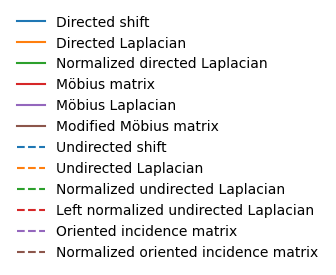

In [49]:

fig_legend = plt.figure(figsize=(4, 3))
ax_legend = fig_legend.add_subplot(111)
ax_legend.axis('off')  # Hide axes

# Assume 'ax' is the axis object from your last plot
handles, labels = ax.get_legend_handles_labels()

# Update labels using your name mapping
friendly_labels = [name_mapping.get(label, label) for label in labels]

# Create a legend with the friendly names
fig_legend.legend(handles, friendly_labels, loc='center', frameon=False)

# Save the legend as a PDF
legend_filename = os.path.join(output_dir, 'plot_legend.pdf')
fig_legend.savefig(legend_filename, format='pdf', bbox_inches='tight')
plt.show()
plt.close(fig_legend)  # Close the figure to free memory



## 12. Standalone Legend Export

A separate legend figure is generated to make layout composition easier in external documents.

This is useful when combining multiple subplots where a single shared legend improves visual clarity and saves space.

In [14]:
import pandas as pd

# Read the CSV file
df = pd.read_csv('ErdosRenyiResults.csv')

# Replace "chicken" with "ham" in the desired column(s)
df['Model Matrix Type'] = df['Model Matrix Type'].str.replace('M_normalizedLaplacianUndirectedDirected', 'M_normalizedLaplacianDirected')

# Save the modified DataFrame back to a CSV file
df.to_csv('ErdosRenyiResults.csv', index=False)

## 13. Result File Post-Processing

This utility step applies targeted string cleanup to harmonize matrix naming in stored CSV outputs.

Consistent naming is essential for reliable grouping, plotting, and downstream aggregation scripts.

In [56]:
import numpy as np
matrices = {}
# Define the matrix A
A = np.array([
    [0, 0, 1, 0, 1],
    [0, 0, 1, 1, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0]
])

A_selfloop = np.copy(A)
for i in range(5):
    A_selfloop[i, i] = 1

# Moebius matrices
closure = transititive_closure(A_selfloop)
M_moebius = np.linalg.inv(closure)
matrices['M_moebius'] = M_moebius

D_M = np.diag(np.sum(M_moebius, axis=0))
M_moebiusLaplacian = M_moebius - D_M
matrices['M_moebiusLaplacian'] = M_moebiusLaplacian

D_modified = np.sum(M_moebius, axis=0) / 5
M_modifiedMoebius = M_moebius - D_modified
matrices['M_modifiedMoebius'] = M_modifiedMoebius
print(matrices)

{'M_moebius': array([[ 1.,  0., -1.,  0.,  0.],
       [ 0.,  1., -1.,  0.,  0.],
       [ 0.,  0.,  1., -1.,  0.],
       [ 0.,  0.,  0.,  1., -1.],
       [ 0.,  0.,  0.,  0.,  1.]]), 'M_moebiusLaplacian': array([[ 0.,  0., -1.,  0.,  0.],
       [ 0.,  0., -1.,  0.,  0.],
       [ 0.,  0.,  2., -1.,  0.],
       [ 0.,  0.,  0.,  1., -1.],
       [ 0.,  0.,  0.,  0.,  1.]]), 'M_modifiedMoebius': array([[ 0.8, -0.2, -0.8,  0. ,  0. ],
       [-0.2,  0.8, -0.8,  0. ,  0. ],
       [-0.2, -0.2,  1.2, -1. ,  0. ],
       [-0.2, -0.2,  0.2,  1. , -1. ],
       [-0.2, -0.2,  0.2,  0. ,  1. ]])}
